<a href="https://colab.research.google.com/github/sarah2005-cyber/auspex/blob/main/Demo_Trained_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎵 Demo — Trained Universal Audio Steganalysis Model
**Run this AFTER training is complete.**

### What this notebook does (top → bottom):
| Section | What happens |
|---|---|
| 1 – Imports & model defs | Pastes the exact same model classes from training notebook |
| 2 – Load checkpoint | Loads best `.pt` checkpoint |
| 3 – Preprocess a raw audio file | `.g729a` → standardised → dual SPM `.npy`|
| 4 – Single-file inference | Runs the model on one file, prints Cover / Stego + confidence |
| 5 – Batch inference | Runs on a whole folder, prints a results table |
| 6 – XAI / Explainability | Dual-stream Grad-CAM heatmaps + stream-attention bar chart |
| 7 – Confusion matrix & ROC | For testing purposes |


---
## 1 — Imports & Model Definitions
The architecture matches the saved weights exactly.

In [ ]:
# ── standard libs ──────────────────────────────────────────────
import os, glob, subprocess
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import librosa
import soundfile as sf
from scipy.signal import convolve2d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cpu


In [ ]:
class ImprovedResidualUnit(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)


class ImprovedSResNetStream(nn.Module):
    def __init__(self, input_channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, 16, 3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(16)
        self.res1  = nn.Sequential(ImprovedResidualUnit(16), ImprovedResidualUnit(16))

        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(32)
        self.res2  = nn.Sequential(ImprovedResidualUnit(32), ImprovedResidualUnit(32))

        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(64)
        self.res3  = nn.Sequential(ImprovedResidualUnit(64), ImprovedResidualUnit(64))

        self.conv4 = nn.Conv2d(64, 128, 3, stride=2, padding=1, bias=False)
        self.bn4   = nn.BatchNorm2d(128)
        self.res4  = ImprovedResidualUnit(128)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)));  x = self.res1(x)
        x = F.relu(self.bn2(self.conv2(x)));  x = self.res2(x)
        x = F.relu(self.bn3(self.conv3(x)));  x = self.res3(x)
        x = F.relu(self.bn4(self.conv4(x)));  x = self.res4(x)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        return x.view(x.size(0), -1)


class ImprovedDualStreamExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared_stream = ImprovedSResNetStream()

    def forward(self, spec1024, spec512):
        return self.shared_stream(spec1024), self.shared_stream(spec512)


class ImprovedScalarAttentionFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(2))

    def forward(self, f1024, f512):
        weights = F.softmax(self.alpha, dim=0)
        fused   = weights[0] * f1024 + weights[1] * f512
        return fused, {'alpha_1024': weights[0].detach(), 'alpha_512': weights[1].detach()}


class ImprovedClassifier(nn.Module):
    def __init__(self, input_dim=128):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.fc(x)


class ImprovedExplainableSteganalysisModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.extractor  = ImprovedDualStreamExtractor()
        self.fusion     = ImprovedScalarAttentionFusion()
        self.classifier = ImprovedClassifier(input_dim=128)

    def forward(self, spec1024, spec512, return_explanations=False):
        f1024, f512 = self.extractor(spec1024, spec512)
        fused, attn = self.fusion(f1024, f512)
        logits      = self.classifier(fused)
        if return_explanations:
            return logits, {
                'stream_attention': attn,
                'features':         {'f1024': f1024.detach().cpu(), 'f512': f512.detach().cpu()},
                'probabilities':    F.softmax(logits, dim=1).detach().cpu()
            }
        return logits, attn

print('✓ Model classes defined.')


✓ Model classes defined.


---
## 2 — Load the Trained Checkpoint

**Edit the `CKPT_PATH` string below** to point to best `.pt` file.

Pick the `*_best_F1*.pt` file (that is the one the training loop flagged as best).

In [ ]:
# ── ✏️  EDIT THIS PATH ─────────────────────────────────────────
CKPT_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/backbone_model_v1/ExplainableSteganalysis_seed9999_best_F10.6392.pt"
# ────────────────────────────────────────────────────────────────

# --- load & verify ---
ckpt  = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model = ImprovedExplainableSteganalysisModel().to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print('✓ Checkpoint loaded.')
print(f"  Best Val F1  : {ckpt.get('best_val_f1',  'N/A')}")
print(f"  Best Val AUC : {ckpt.get('best_val_auc', 'N/A')}")
print(f"  Saved epoch  : {ckpt.get('epoch',        'N/A')}")


✓ Checkpoint loaded.
  Best Val F1  : 0.6392147474263826
  Best Val AUC : 0.4876195555555556
  Saved epoch  : 8


---
## 3 — Preprocessing Helpers
These replicate **exactly** the same steps from `Preprocessing_steps.ipynb`:
`raw audio → ffmpeg decode → standardise (44 kHz, mono, 1 s) → log-mag STFT → SPM filter → .npy`

Drop **any** `.g729a` file in and get the two spectrogram arrays the model expects.

In [ ]:
# ── constants ─────────────
TARGET_SR       = 44100
TARGET_LEN      = TARGET_SR * 1
MAX_FRAMES_1024 = 87
MAX_FRAMES_512  = 173
EPS             = 1e-8

KERNEL_STRONG = np.array([[-1,-1,-1],[-1, 8,-1],[-1,-1,-1]], dtype=np.float32)
KERNEL_LIGHT  = np.array([[ 0,-1, 0],[-1, 4,-1],[ 0,-1, 0]], dtype=np.float32)

# ── step 1: decode .g729a → .wav  (ffmpeg) ────────────
def decode_to_wav(input_path: str, output_wav: str):

    if input_path.endswith('.wav'):
        import shutil; shutil.copy(input_path, output_wav); return

    if input_path.endswith('.pcm'):
        cmd = ['ffmpeg','-y','-f','s16le','-ar','8000','-ac','1',
               '-i', input_path, '-ar','44100', output_wav]
    else:   # .g729a
        cmd = ['ffmpeg','-y','-f','g729','-i', input_path,
               '-ar','44100','-ac','1', output_wav]

    subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)

# ── step 2: standardise ──
def standardize_audio(wav_path: str) -> np.ndarray:
    """Returns a 1-D float64 array of exactly TARGET_LEN samples, peak-normalised."""
    audio, sr = sf.read(wav_path)
    if sr != TARGET_SR:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=TARGET_SR)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)

    if len(audio) > TARGET_LEN:  audio = audio[:TARGET_LEN]
    elif len(audio) < TARGET_LEN: audio = np.pad(audio, (0, TARGET_LEN - len(audio)))

    peak = np.max(np.abs(audio))
    if peak > 0: audio = audio / peak
    return audio

# ── step 3: log-mag STFT + min-max norm + pad/trim ────────────
def compute_log_norm_padded_spec(audio, n_fft, hop_length, max_frames):
    S     = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length, window='hamming'))
    S_log = np.log10(S + EPS)
    s_min, s_max = S_log.min(), S_log.max()
    S_norm = (S_log - s_min) / (s_max - s_min + EPS)
    freq_bins, time_frames = S_norm.shape
    if time_frames < max_frames:
        S_norm = np.pad(S_norm, ((0,0),(0, max_frames - time_frames)))
    else:
        S_norm = S_norm[:, :max_frames]
    return S_norm

# ── step 4: SPM high-pass filtering (same kernels & weights) ──
def apply_spm_filters(spec, kernels, weights=None):
    if weights is None: weights = [1.0]*len(kernels)
    out = np.zeros_like(spec)
    for ker, w in zip(kernels, weights):
        out += w * convolve2d(spec, ker, mode='same', boundary='symm')
    out = np.maximum(out, 0.0)
    fmin, fmax = out.min(), out.max()
    return np.zeros_like(out) if (fmax - fmin) < EPS else (out - fmin) / (fmax - fmin + EPS)

# ── MASTER: raw file → (tensor_1024, tensor_512) ─────────────
def preprocess_file(input_path: str):
    import tempfile
    tmp_wav = os.path.join(tempfile.gettempdir(), '_stego_demo.wav')
    decode_to_wav(input_path, tmp_wav)
    audio = standardize_audio(tmp_wav)

    # 1024-window SPM  (strong + light, same weights as training)
    spec1024 = compute_log_norm_padded_spec(audio, n_fft=1024, hop_length=512,  max_frames=MAX_FRAMES_1024)
    spm1024  = apply_spm_filters(spec1024, kernels=[KERNEL_STRONG, KERNEL_LIGHT], weights=[1.0, 0.5])

    # 512-window SPM  (light only)
    spec512  = compute_log_norm_padded_spec(audio, n_fft=512,  hop_length=256,  max_frames=MAX_FRAMES_512)
    spm512   = apply_spm_filters(spec512,  kernels=[KERNEL_LIGHT], weights=[1.0])

    # → tensors with channel dim  (1, F, T)
    t1024 = torch.tensor(spm1024, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    t512  = torch.tensor(spm512,  dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
    return t1024, t512, spm1024, spm512

print('✓ Preprocessing helpers ready.')


✓ Preprocessing helpers ready.


---
## 4 — Single-File Inference

**Edit `AUDIO_FILE`** to point to any `.g729a` file.

It will print:
* **Cover / Stego** verdict
* Confidence percentage
* Learned stream-attention weights (how much the model relied on each spectrogram resolution)

In [ ]:
# ── ✏️  EDIT THIS PATH ─────────────────────────────────────────
AUDIO_FILE = "/content/Chinese2.g729a"
# ────────────────────────────────────────────────────────────────

# ── run ────────────────────────────────────────────────────────
t1024, t512, raw1024, raw512 = preprocess_file(AUDIO_FILE)

model.eval()
with torch.no_grad():
    logits, explanations = model(t1024, t512, return_explanations=True)

probs     = explanations['probabilities'][0]
pred_idx  = probs.argmax().item()
label_map = {0: 'COVER (clean)', 1: 'STEGO (embedded)'}

alpha_1024 = explanations['stream_attention']['alpha_1024'].item()
alpha_512  = explanations['stream_attention']['alpha_512'].item()

print('=' * 60)
print(f"  FILE : {os.path.basename(AUDIO_FILE)}")
print(f"  VERDICT : {label_map[pred_idx]}")
print(f"  Confidence : {probs[pred_idx]*100:.2f} %")
print(f"  P(cover)   : {probs[0]*100:.2f} %")
print(f"  P(stego)   : {probs[1]*100:.2f} %")
print('-' * 60)
print(f"  Stream attention weights (learned):")
print(f"    1024-FFT stream : {alpha_1024:.4f}")
print(f"     512-FFT stream : {alpha_512:.4f}")
dominant = '1024-FFT (coarser freq, longer frames)' if alpha_1024 > alpha_512 else '512-FFT (finer freq, shorter frames)'
print(f"    → Model relied more on the {dominant} stream")
print('=' * 60)


  FILE : Chinese2.g729a
  VERDICT : STEGO (embedded)
  Confidence : 53.71 %
  P(cover)   : 46.29 %
  P(stego)   : 53.71 %
------------------------------------------------------------
  Stream attention weights (learned):
    1024-FFT stream : 0.5060
     512-FFT stream : 0.4940
    → Model relied more on the 1024-FFT (coarser freq, longer frames) stream


---
## 5 — Batch Inference on a Folder

Drop a folder full of `.g729a` files and get a DataFrame out.

**Edit `AUDIO_FOLDER`** below.

In [ ]:
# ── ✏️  EDIT THIS PATH ─────────────────────────────────────────
AUDIO_FOLDER = "/content/test_audio"
# ────────────────────────────────────────────────────────────────

SUPPORTED_EXT = ('.g729a', '.wav', '.pcm')

files = sorted([f for f in os.listdir(AUDIO_FOLDER) if f.lower().endswith(SUPPORTED_EXT)])
print(f'Found {len(files)} audio files.')

rows = []
model.eval()
for fname in tqdm(files):
    fpath = os.path.join(AUDIO_FOLDER, fname)
    try:
        t1024, t512, _, _ = preprocess_file(fpath)
        with torch.no_grad():
            logits, expl = model(t1024, t512, return_explanations=True)
        p = expl['probabilities'][0]
        rows.append({
            'file':       fname,
            'prediction': 'STEGO' if p[1] > p[0] else 'COVER',
            'P(cover)%':  round(p[0].item()*100, 2),
            'P(stego)%':  round(p[1].item()*100, 2),
            'α_1024':     round(expl['stream_attention']['alpha_1024'].item(), 4),
            'α_512' :     round(expl['stream_attention']['alpha_512'].item(),  4),
        })
    except Exception as e:
        rows.append({'file': fname, 'prediction': f'ERROR: {e}',
                     'P(cover)%': None, 'P(stego)%': None, 'α_1024': None, 'α_512': None})

results_df = pd.DataFrame(rows)
print(results_df.to_string(index=False))

# optional: save
results_df.to_csv('/content/batch_inference_results.csv', index=False)
print('\n✓ Saved to /content/batch_inference_results.csv')


Found 5 audio files.


100%|██████████| 5/5 [00:01<00:00,  3.84it/s]

            file prediction  P(cover)%  P(stego)%  α_1024  α_512
Chinese101.g729a      STEGO      42.32      57.68   0.506  0.494
Chinese195.g729a      STEGO      44.35      55.65   0.506  0.494
Chinese317.g729a      STEGO      27.12      72.88   0.506  0.494
Chinese387.g729a      STEGO      48.49      51.51   0.506  0.494
  Chinese8.g729a      STEGO      48.62      51.38   0.506  0.494

✓ Saved to /content/batch_inference_results.csv


---
## 6 — XAI: Grad-CAM + Stream Attention Visualisation

This produces a **4-panel figure** for the file already run in Section 4:

| Panel | Shows |
|---|---|
| Top-left | Raw SPM spectrogram (1024-window) |
| Top-right | Raw SPM spectrogram (512-window) |
| Bottom-left | Grad-CAM heatmap overlaid on 1024-spectrogram |
| Bottom-right | Grad-CAM heatmap overlaid on 512-spectrogram |

Plus a small bar chart of the learned stream-attention weights.

> **How the dual Grad-CAM works:** The shared backbone (`shared_stream`) is called once for each spectrogram. Hook `conv4` (the deepest conv layer), run a separate backward pass for each stream's contribution, and get two independent heatmaps.

In [ ]:
# ── Grad-CAM engine (works for either stream) ────────────────

class DualStreamGradCAM:
    """
    Produces one CAM per stream by hooking shared_stream.conv4.
    Because the shared stream is called TWICE (once per input),
    the hook fires twice — we collect both activations / grads.
    """
    def __init__(self, model):
        self.model = model
        self.target_layer = model.extractor.shared_stream.conv4
        self.activations = []
        self.gradients   = []

        self.fwd_handle = self.target_layer.register_forward_hook(self._save_act)
        self.bwd_handle = self.target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, module, inp, out):
        self.activations.append(out.detach().clone())

    def _save_grad(self, module, grad_in, grad_out):
        self.gradients.append(grad_out[0].detach().clone())

    def compute(self, spec1024, spec512):
        """
        Returns cam_1024, cam_512  — each normalised to [0, 1].
        """
        self.activations.clear()
        self.gradients.clear()
        self.model.zero_grad()

        # forward
        logits, _ = self.model(spec1024, spec512)
        pred_class = logits.argmax(dim=1).item()

        # backward on predicted class score
        logits[0, pred_class].backward()

        # --- build CAMs ---
        cams = []
        for act, grad in zip(self.activations, self.gradients):
            weights = grad.mean(dim=(2, 3), keepdim=True)
            cam     = (weights * act).sum(dim=1)
            cam     = F.relu(cam)
            cam     = cam - cam.min()
            cam     = cam / (cam.max() + 1e-8)
            cams.append(cam[0].cpu().numpy())

        return cams[0], cams[1], pred_class

    def remove_hooks(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()


def resize_cam(cam, target_h, target_w):
    return cv2.resize(cam.astype(np.float32), (target_w, target_h))

print('✓ DualStreamGradCAM class ready.')


✓ DualStreamGradCAM class ready.


In [ ]:
# (re-preprocess so the tensors require grad for backward for chosen audio file)

t1024, t512, raw1024, raw512 = preprocess_file(AUDIO_FILE)
t1024.requires_grad_(True)
t512.requires_grad_(True)

gradcam = DualStreamGradCAM(model)
cam_1024, cam_512, pred_class = gradcam.compute(t1024, t512)
gradcam.remove_hooks()

cam_1024_resized = resize_cam(cam_1024, raw1024.shape[0], raw1024.shape[1])
cam_512_resized  = resize_cam(cam_512,  raw512.shape[0],  raw512.shape[1])

print(f'✓ Grad-CAM computed.  Predicted class: {pred_class} ({label_map[pred_class]})')


✓ Grad-CAM computed.  Predicted class: 1 (STEGO (embedded))


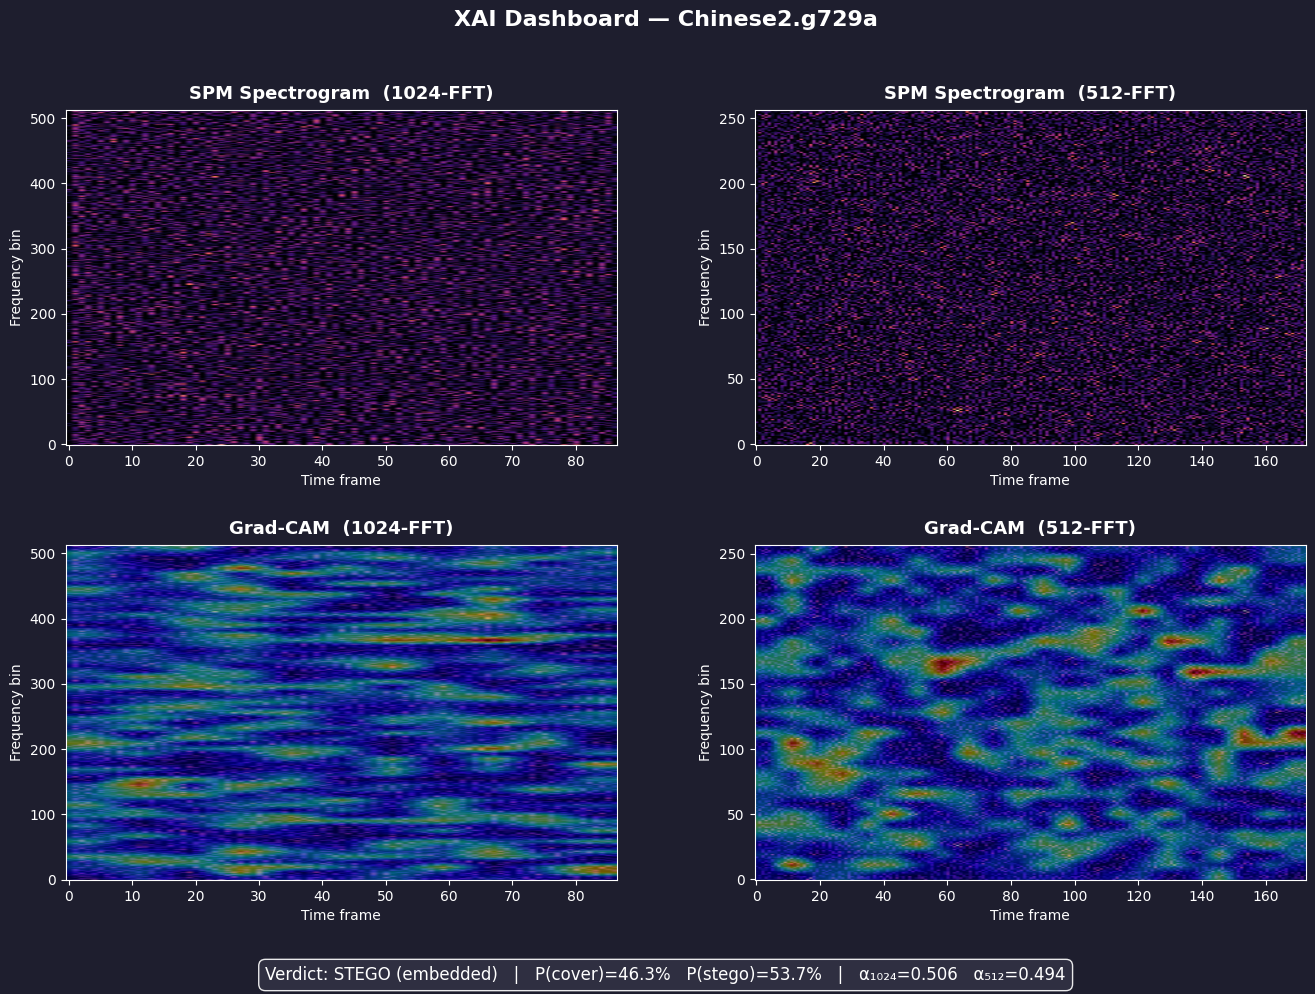

✓ Saved to /content/gradcam_dashboard.png


In [ ]:
# ── 4-panel figure + attention bar ────────────────────────────

fig  = plt.figure(figsize=(16, 10), facecolor='#1e1e2e')
gs   = gridspec.GridSpec(2, 2, hspace=0.3, wspace=0.25)

titles = ['SPM Spectrogram  (1024-FFT)', 'SPM Spectrogram  (512-FFT)',
          'Grad-CAM  (1024-FFT)',        'Grad-CAM  (512-FFT)']
specs  = [raw1024, raw512, raw1024, raw512]
cams   = [None, None, cam_1024_resized, cam_512_resized]

for i, (ax_idx, title, spec, cam) in enumerate(zip(range(4), titles, specs, cams)):
    ax = fig.add_subplot(gs[ax_idx // 2, ax_idx % 2])
    ax.set_facecolor('#1e1e2e')

    # base spectrogram
    im = ax.imshow(spec, aspect='auto', origin='lower', cmap='magma')

    # overlay CAM
    if cam is not None:
        ax.imshow(cam, aspect='auto', origin='lower', cmap='jet', alpha=0.45)

    ax.set_title(title, color='white', fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Time frame', color='white')
    ax.set_ylabel('Frequency bin', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_color('white')

# ── verdict + attention bar ──────
fig.text(0.5, 0.01,
         f"Verdict: {label_map[pred_class]}   |   "
         f"P(cover)={probs[0]*100:.1f}%   P(stego)={probs[1]*100:.1f}%   |   "
         f"α₁₀₂₄={alpha_1024:.3f}   α₅₁₂={alpha_512:.3f}",
         ha='center', fontsize=12, color='white',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#313244', edgecolor='white', alpha=0.9))

plt.suptitle(f'XAI Dashboard — {os.path.basename(AUDIO_FILE)}',
             color='white', fontsize=16, fontweight='bold', y=0.98)
plt.savefig('/content/gradcam_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('✓ Saved to /content/gradcam_dashboard.png')


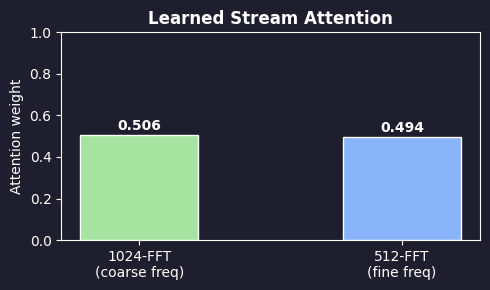

In [ ]:
# ── Stream-attention bar chart (standalone) ──────────────────

fig, ax = plt.subplots(figsize=(5, 3), facecolor='#1e1e2e')
ax.set_facecolor('#1e1e2e')

bars = ax.bar(['1024-FFT\n(coarse freq)', '512-FFT\n(fine freq)'],
              [alpha_1024, alpha_512],
              color=['#a6e3a1', '#89b4fa'], edgecolor='white', width=0.45)

# value labels
for bar, val in zip(bars, [alpha_1024, alpha_512]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', color='white', fontweight='bold')

ax.set_ylim(0, 1)
ax.set_ylabel('Attention weight', color='white')
ax.set_title('Learned Stream Attention', color='white', fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('white')
plt.tight_layout()
plt.savefig('/content/stream_attention_bar.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()


---
## 7 — (Optional) Test-Set Evaluation: Confusion Matrix + ROC

If need to evaluate on held-out **test set** (not just single files),
run this cell. It reuses `test_loader` from the training notebook —
just re-run the dataset-splitting cell first so that variable exists.

Edit `test_loader` below if the variable name is different.

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc as sk_auc, classification_report


all_labels, all_probs = [], []
model.eval()
with torch.no_grad():
    for spec1024, spec512, label in tqdm(test_loader, desc='Test set'):
        spec1024 = spec1024.to(device)
        spec512  = spec512.to(device)
        logits, _ = model(spec1024, spec512)
        probs_batch = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_labels.extend(label.numpy())
        all_probs.extend(probs_batch)

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
all_preds  = (all_probs >= 0.5).astype(int)

print(classification_report(all_labels, all_preds, target_names=['Cover', 'Stego']))

# ── 2-panel: Confusion Matrix  |  ROC Curve ───────────────────
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc     = sk_auc(fpr, tpr)
cm          = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#1e1e2e')

# -- confusion matrix --
ax = axes[0]; ax.set_facecolor('#1e1e2e')
im = ax.imshow(cm, cmap='YlOrRd', aspect='auto')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=20, fontweight='bold')
ax.set_xticks([0,1]); ax.set_xticklabels(['Pred Cover','Pred Stego'], color='white')
ax.set_yticks([0,1]); ax.set_yticklabels(['True Cover','True Stego'], color='white')
ax.set_title('Confusion Matrix', color='white', fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('white')

# -- ROC --
ax = axes[1]; ax.set_facecolor('#1e1e2e')
ax.plot(fpr, tpr, color='#a6e3a1', lw=2.5, label=f'AUC = {roc_auc:.4f}')
ax.plot([0,1], [0,1], color='white', linestyle='--', lw=1)
ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate', color='white')
ax.set_title('ROC Curve', color='white', fontweight='bold')
ax.legend(loc='lower right', facecolor='#313244', edgecolor='white',
          labelcolor='white', fontsize=12)
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_color('white')

plt.tight_layout()
plt.savefig('/content/test_eval.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'✓ Test-set AUC: {roc_auc:.4f}')
